# ENSO RL — Analysis Notebook

All figures and tables for the paper. Run computation scripts first to generate `.npz`/`.csv` files, then use this notebook to produce publication-quality plots without recomputing.

**Computation scripts** (run from repo root):
```bash
# Unified inference (lift + seasonality raw data)
uv run scripts/analysis/inference.py               --model ensemble

# XAI methods (each independent)
uv run scripts/analysis/counterfactual_analysis.py --model ensemble
uv run scripts/analysis/shapley_analysis.py        --model ensemble
uv run scripts/analysis/interventional_xro.py      --model ensemble
uv run scripts/analysis/precursor_composite.py     --model ensemble
uv run scripts/analysis/mutual_information.py      --model ensemble
uv run scripts/analysis/integrated_gradients.py    --model ensemble
uv run scripts/analysis/gradient_sensitivity.py    --model ensemble
```

## Setup

In [40]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.stats import spearmanr, ttest_1samp
from scipy.stats import t as t_dist

sys.path.insert(0, str(Path("..").resolve()))
from utils.enso_classifier import _find_continuous_runs
from utils.nb_helper import (
    PHASES, PHASE_LABELS, PHASE_COLORS, XRO_MODES, SPINUP, PHASE_MASKS,
    _zscore, _sig_stars, _add_sig_labels, _mean_ci, _load_npz,
)

NAME = "rng-action"   # matches --model used when running computation scripts
BASE = Path("..") / "plots" / NAME

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print(f"BASE = {BASE.resolve()}")

BASE = /Users/ayman/research/enso-rl/plots/rng-action


---
## 1. Trajectory Diagnostics

Single-trajectory and distribution diagnostics ported from the retired `evaluate.py`:
Nino3.4 with month-by-month phase classification, the styled ENSO table, raw
state/action time series, and action/state distributions resolved by ENSO phase.
All data comes from the same `inference.npz` raw rollouts used in the rest of the notebook.

In [41]:
# Raw rollouts (same file the lift section loads later)
d_inf = _load_npz(BASE / "inference.npz")
THRESHOLD = 0.5   # ENSO event threshold (matches EnvConfig.threshold)

# Int8 MYE-label encoding produced by inference.py
LABEL_NAMES = {0: 'Neutral',
               1: 'Single-year El Nino', 2: 'Single-year La Nina',
               3: 'Multi-year El Nino',  4: 'Multi-year La Nina'}

traj_var_names    = list(d_inf['var_names'])     # ['Nino34', 'WWV', ...] (10)
traj_action_names = list(d_inf['action_names'])  # forcing modes (9)

n_seeds, n_rollouts = d_inf['agent_obs'].shape[:2]

# ============================================================================
# >>> CHANGE THESE to pick which ensemble rollout plots 0a-0d show <<<
SEED_IDX    = 4   # ensemble member       (0 .. n_seeds-1)
ROLLOUT_IDX = 0   # rollout of that member (0 .. n_rollouts-1)
# ============================================================================

assert 0 <= SEED_IDX < n_seeds,       f"SEED_IDX must be in 0..{n_seeds-1}"
assert 0 <= ROLLOUT_IDX < n_rollouts, f"ROLLOUT_IDX must be in 0..{n_rollouts-1}"

states_traj  = d_inf['agent_obs'][SEED_IDX, ROLLOUT_IDX]        # [T, 10]
actions_traj = d_inf['agent_actions'][SEED_IDX, ROLLOUT_IDX]    # [T, 9]
labels_traj  = d_inf['agent_mye_label'][SEED_IDX, ROLLOUT_IDX]  # [T] int8
enso_traj    = states_traj[:, 0]                               # Nino3.4 column
T_traj       = len(enso_traj)

# True calendar month of step 0 for this rollout (0=Jan); aligns the ENSO table.
start_month_sel = (int(d_inf['rollout_start_month'][SEED_IDX, ROLLOUT_IDX])
                   if 'rollout_start_month' in d_inf.files else 0)

print(f"Ensemble: {n_seeds} seeds x {n_rollouts} rollouts   "
      f"(seed_idx 0..{n_seeds-1}, rollout_idx 0..{n_rollouts-1})")
print(f"Showing  : seed_idx={SEED_IDX}, rollout_idx={ROLLOUT_IDX}, T={T_traj} months")
print("Phase month counts:",
      {LABEL_NAMES[k]: int((labels_traj == k).sum()) for k in LABEL_NAMES})

Ensemble: 5 seeds x 30 rollouts   (seed_idx 0..4, rollout_idx 0..29)
Showing  : seed_idx=4, rollout_idx=0, T=1200 months
Phase month counts: {'Neutral': 245, 'Single-year El Nino': 34, 'Single-year La Nina': 0, 'Multi-year El Nino': 365, 'Multi-year La Nina': 556}


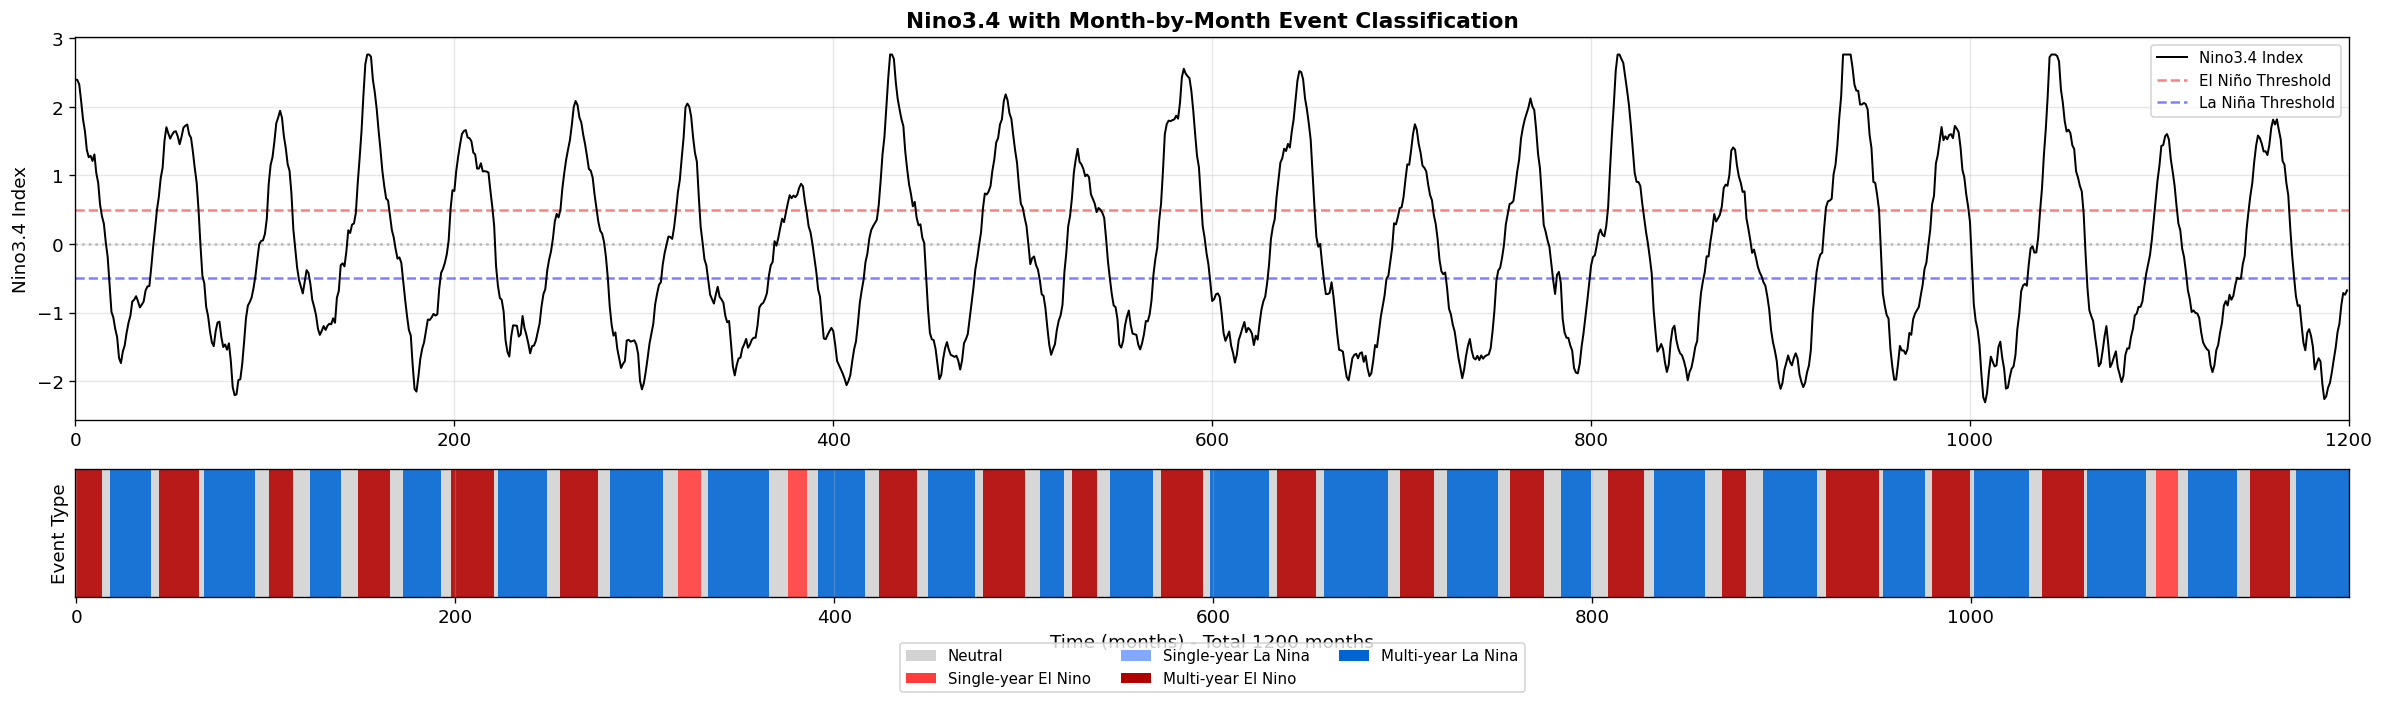

In [42]:
from matplotlib.patches import Patch

phase_color_map = {
    0: '#D3D3D3',  # Neutral
    1: '#FF3C3C',  # Single-year El Nino
    2: '#82A8FF',  # Single-year La Nina
    3: '#B10000',  # Multi-year El Nino
    4: '#0065D1',  # Multi-year La Nina
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6), height_ratios=[3, 1])

ax1.plot(enso_traj, linewidth=1.2, label='Nino3.4 Index', color='black', zorder=3)
ax1.set_xlim(0, T_traj)
ax1.axhline(THRESHOLD,  color='r', linestyle='--', alpha=0.5, linewidth=1.5, label='El Niño Threshold')
ax1.axhline(-THRESHOLD, color='b', linestyle='--', alpha=0.5, linewidth=1.5, label='La Niña Threshold')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax1.set_title("Nino3.4 with Month-by-Month Event Classification", fontsize=13, fontweight='bold')
ax1.set_ylabel("Nino3.4 Index")
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

bar_colors = [phase_color_map[int(l)] for l in labels_traj]
ax2.bar(range(T_traj), np.ones(T_traj), color=bar_colors, width=1, edgecolor='none', alpha=0.9)
ax2.set_xlim(-0.5, T_traj - 0.5)
ax2.set_ylim(0, 1)
ax2.set_xlabel(f"Time (months) - Total {T_traj} months")
ax2.set_yticks([])
ax2.set_ylabel("Event Type")
ax2.grid(True, alpha=0.3, axis='x')

legend_elements = [Patch(facecolor=phase_color_map[k], label=LABEL_NAMES[k]) for k in phase_color_map]
ax2.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, -0.3), frameon=True, fontsize=9)

fig.tight_layout()
plt.show()

In [43]:
from utils.enso_table import create_enso_table, style_enso_table, save_enso_table_html
from IPython.display import display, HTML

# Calendar-aligned: columns are fixed DJF..NDJ; cells before/after the rollout
# (and any partial first/last year) are left blank.
df_enso = create_enso_table(enso_traj, threshold=THRESHOLD, start_month=start_month_sel)
styler  = style_enso_table(df_enso, threshold=THRESHOLD)

# Save interactive HTML alongside the other rng-action plots
out_html = BASE / "enso_table.html"
save_enso_table_html(enso_traj, output_path=str(out_html), threshold=THRESHOLD,
                     start_month=start_month_sel)
print(f"Saved -> {out_html.resolve()}")

# Render inline (red = El Niño, blue = La Niña, peaks bolded)
display(HTML(styler.to_html()))

Saved -> /Users/ayman/research/enso-rl/plots/rng-action/enso_table.html


,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
Year,,,,,,,,,,,,
1,2.39,2.39,2.32,2.08,1.81,1.64,1.37,1.26,1.28,1.21,1.30,1.03
2,0.89,0.57,0.40,0.29,0.02,-0.19,-0.60,-0.99,-1.07,-1.24,-1.36,-1.66
3,-1.74,-1.57,-1.48,-1.29,-1.15,-1.05,-0.84,-0.81,-0.76,-0.84,-0.93,-0.89
4,-0.84,-0.68,-0.62,-0.61,-0.35,-0.05,0.21,0.49,0.68,0.96,1.11,1.51
5,1.70,1.61,1.53,1.59,1.63,1.64,1.57,1.45,1.56,1.69,1.72,1.74
6,1.60,1.55,1.34,1.10,0.89,0.48,-0.03,-0.46,-0.57,-0.92,-1.05,-1.27
7,-1.43,-1.49,-1.27,-1.15,-1.13,-1.35,-1.50,-1.47,-1.54,-1.45,-1.70,-2.09
8,-2.20,-2.19,-1.98,-1.97,-1.76,-1.43,-1.09,-0.90,-0.85,-0.78,-0.64,-0.47
9,-0.23,-0.01,0.04,0.05,0.15,0.37,0.87,1.15,1.26,1.49,1.76,1.84


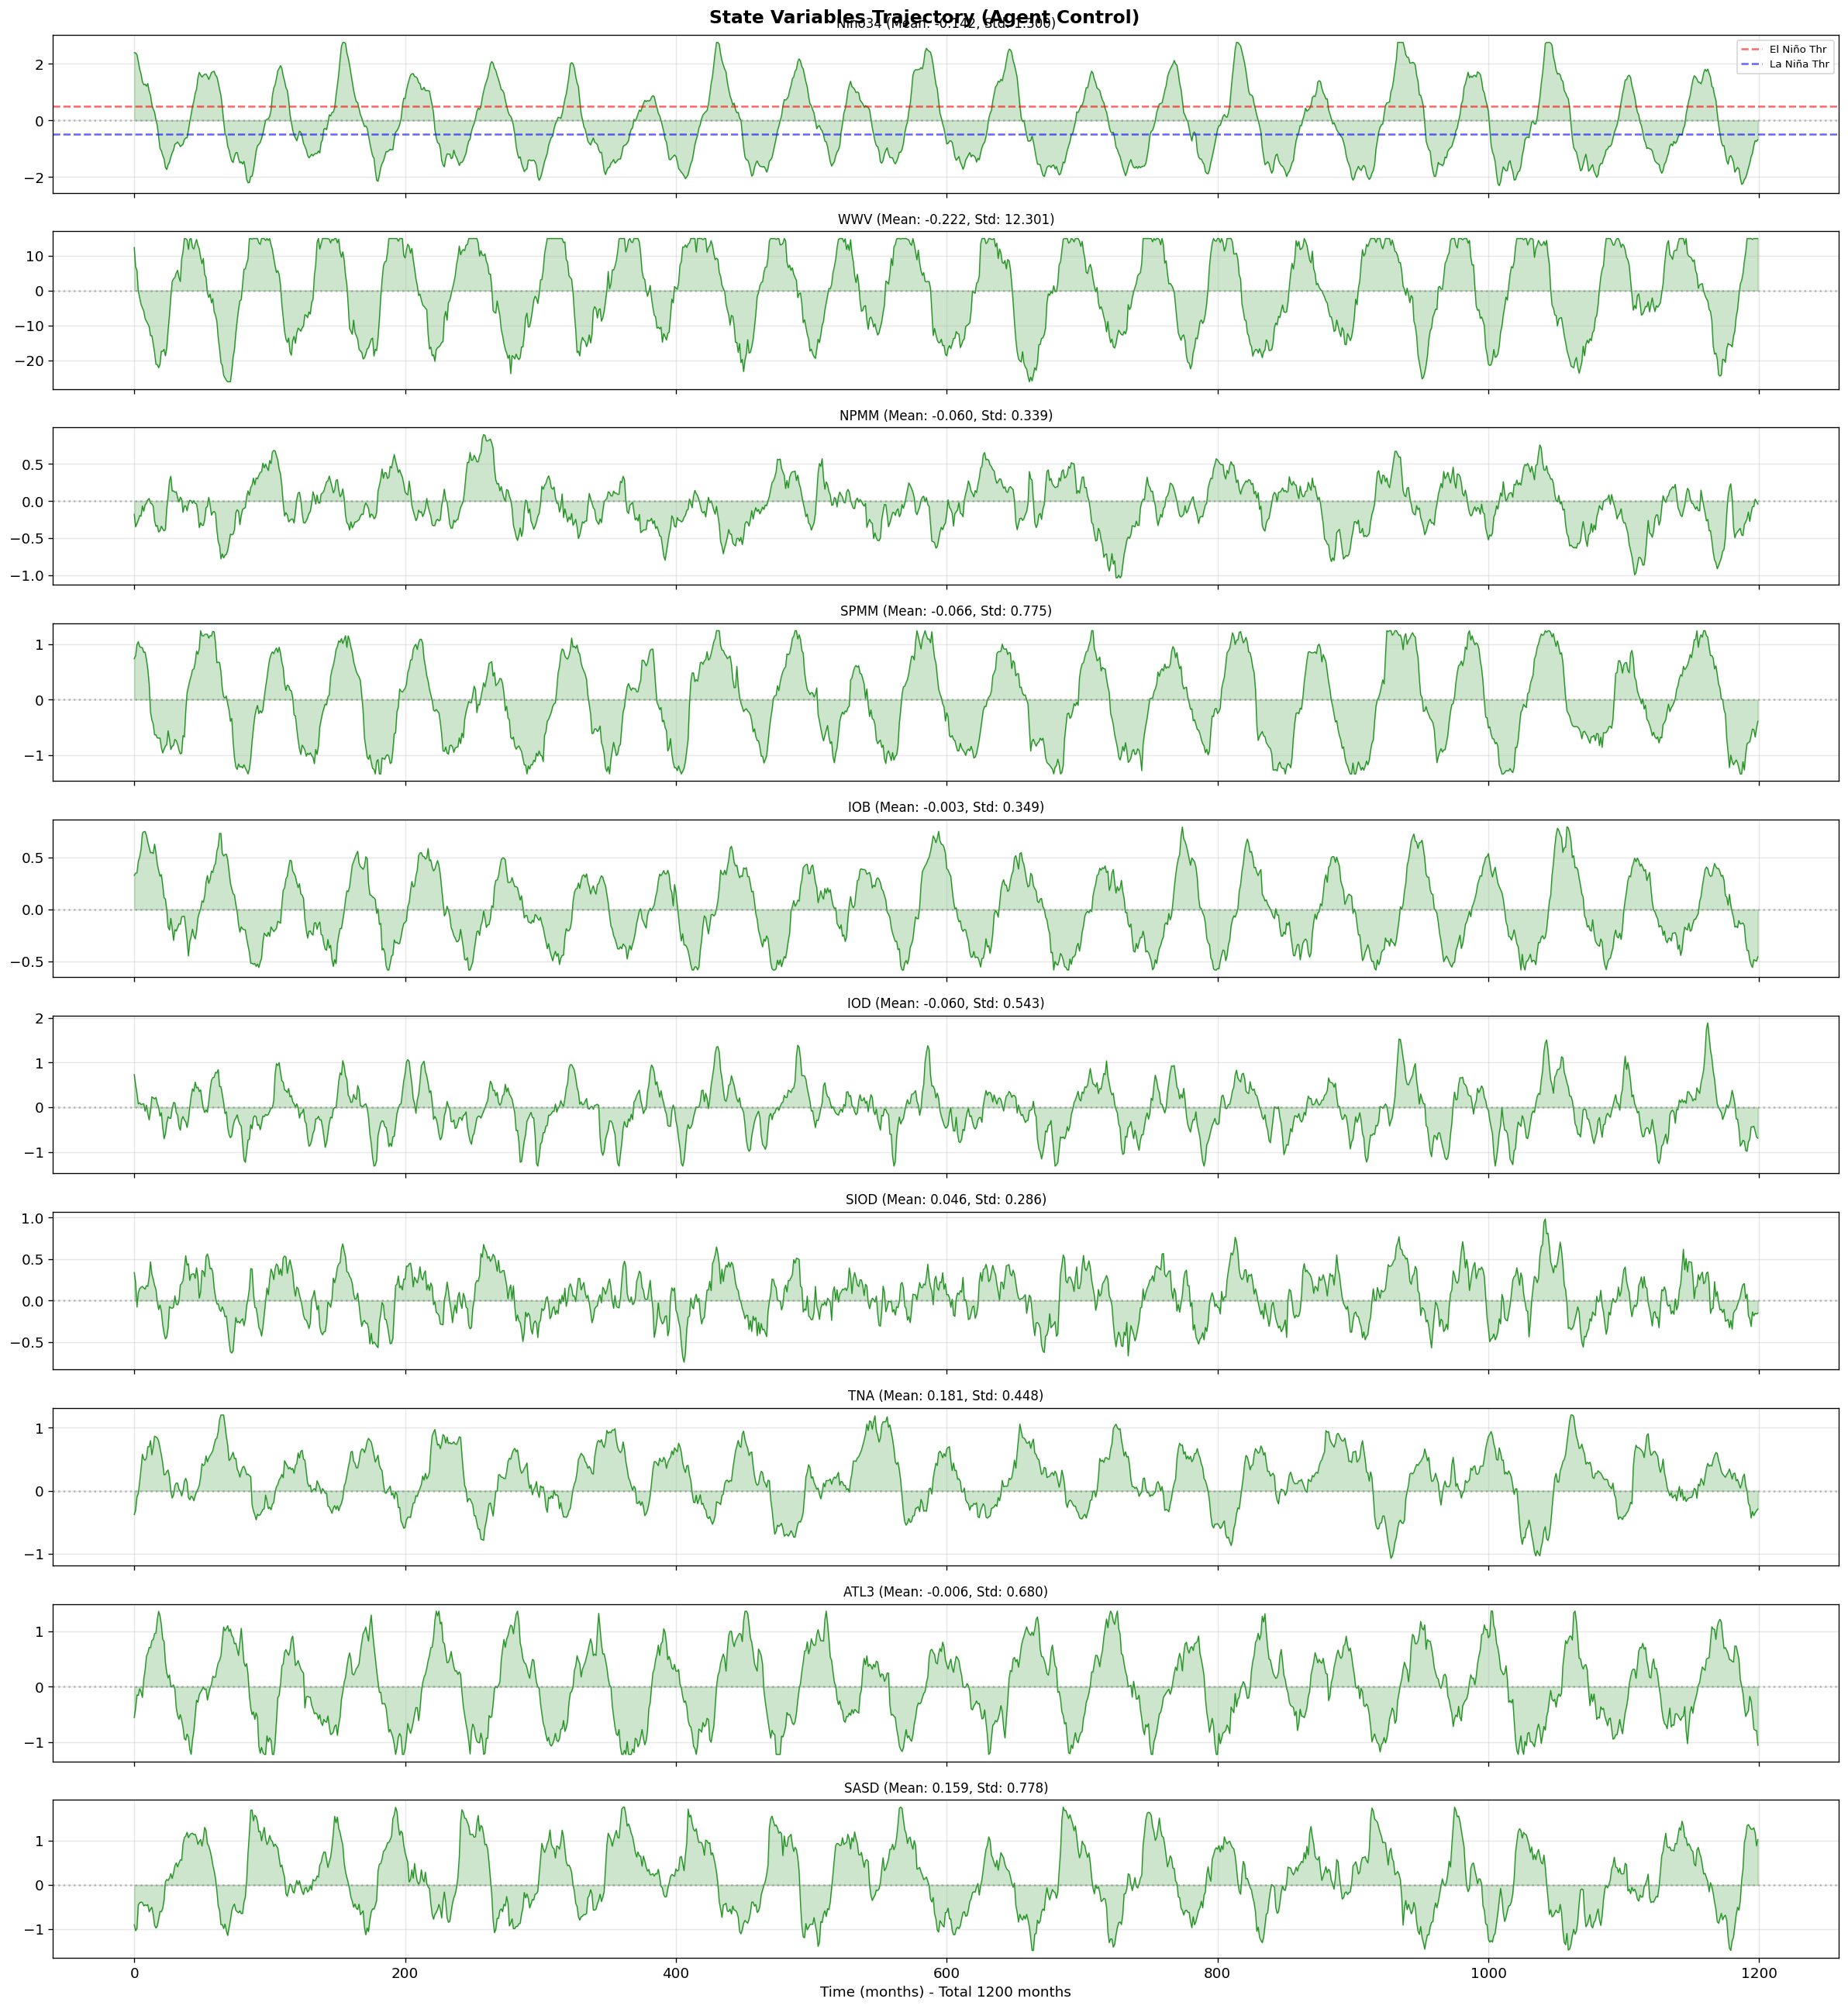

In [44]:
n_vars = len(traj_var_names)
fig, axes = plt.subplots(n_vars, 1, figsize=(20, n_vars * 2.2), sharex=True)
fig.suptitle("State Variables Trajectory (Agent Control)", fontsize=14, fontweight='bold')

for i, vname in enumerate(traj_var_names):
    ax = axes[i]
    ax.plot(states_traj[:, i], linewidth=0.8, color='green', alpha=0.8)
    ax.fill_between(range(T_traj), states_traj[:, i], alpha=0.2, color='green')
    if vname == 'Nino34':
        ax.axhline(THRESHOLD,  color='r', linestyle='--', alpha=0.6, label='El Niño Thr')
        ax.axhline(-THRESHOLD, color='b', linestyle='--', alpha=0.6, label='La Niña Thr')
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{vname} (Mean: {states_traj[:, i].mean():.3f}, Std: {states_traj[:, i].std():.3f})',
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel(f"Time (months) - Total {T_traj} months")
fig.tight_layout()
plt.show()

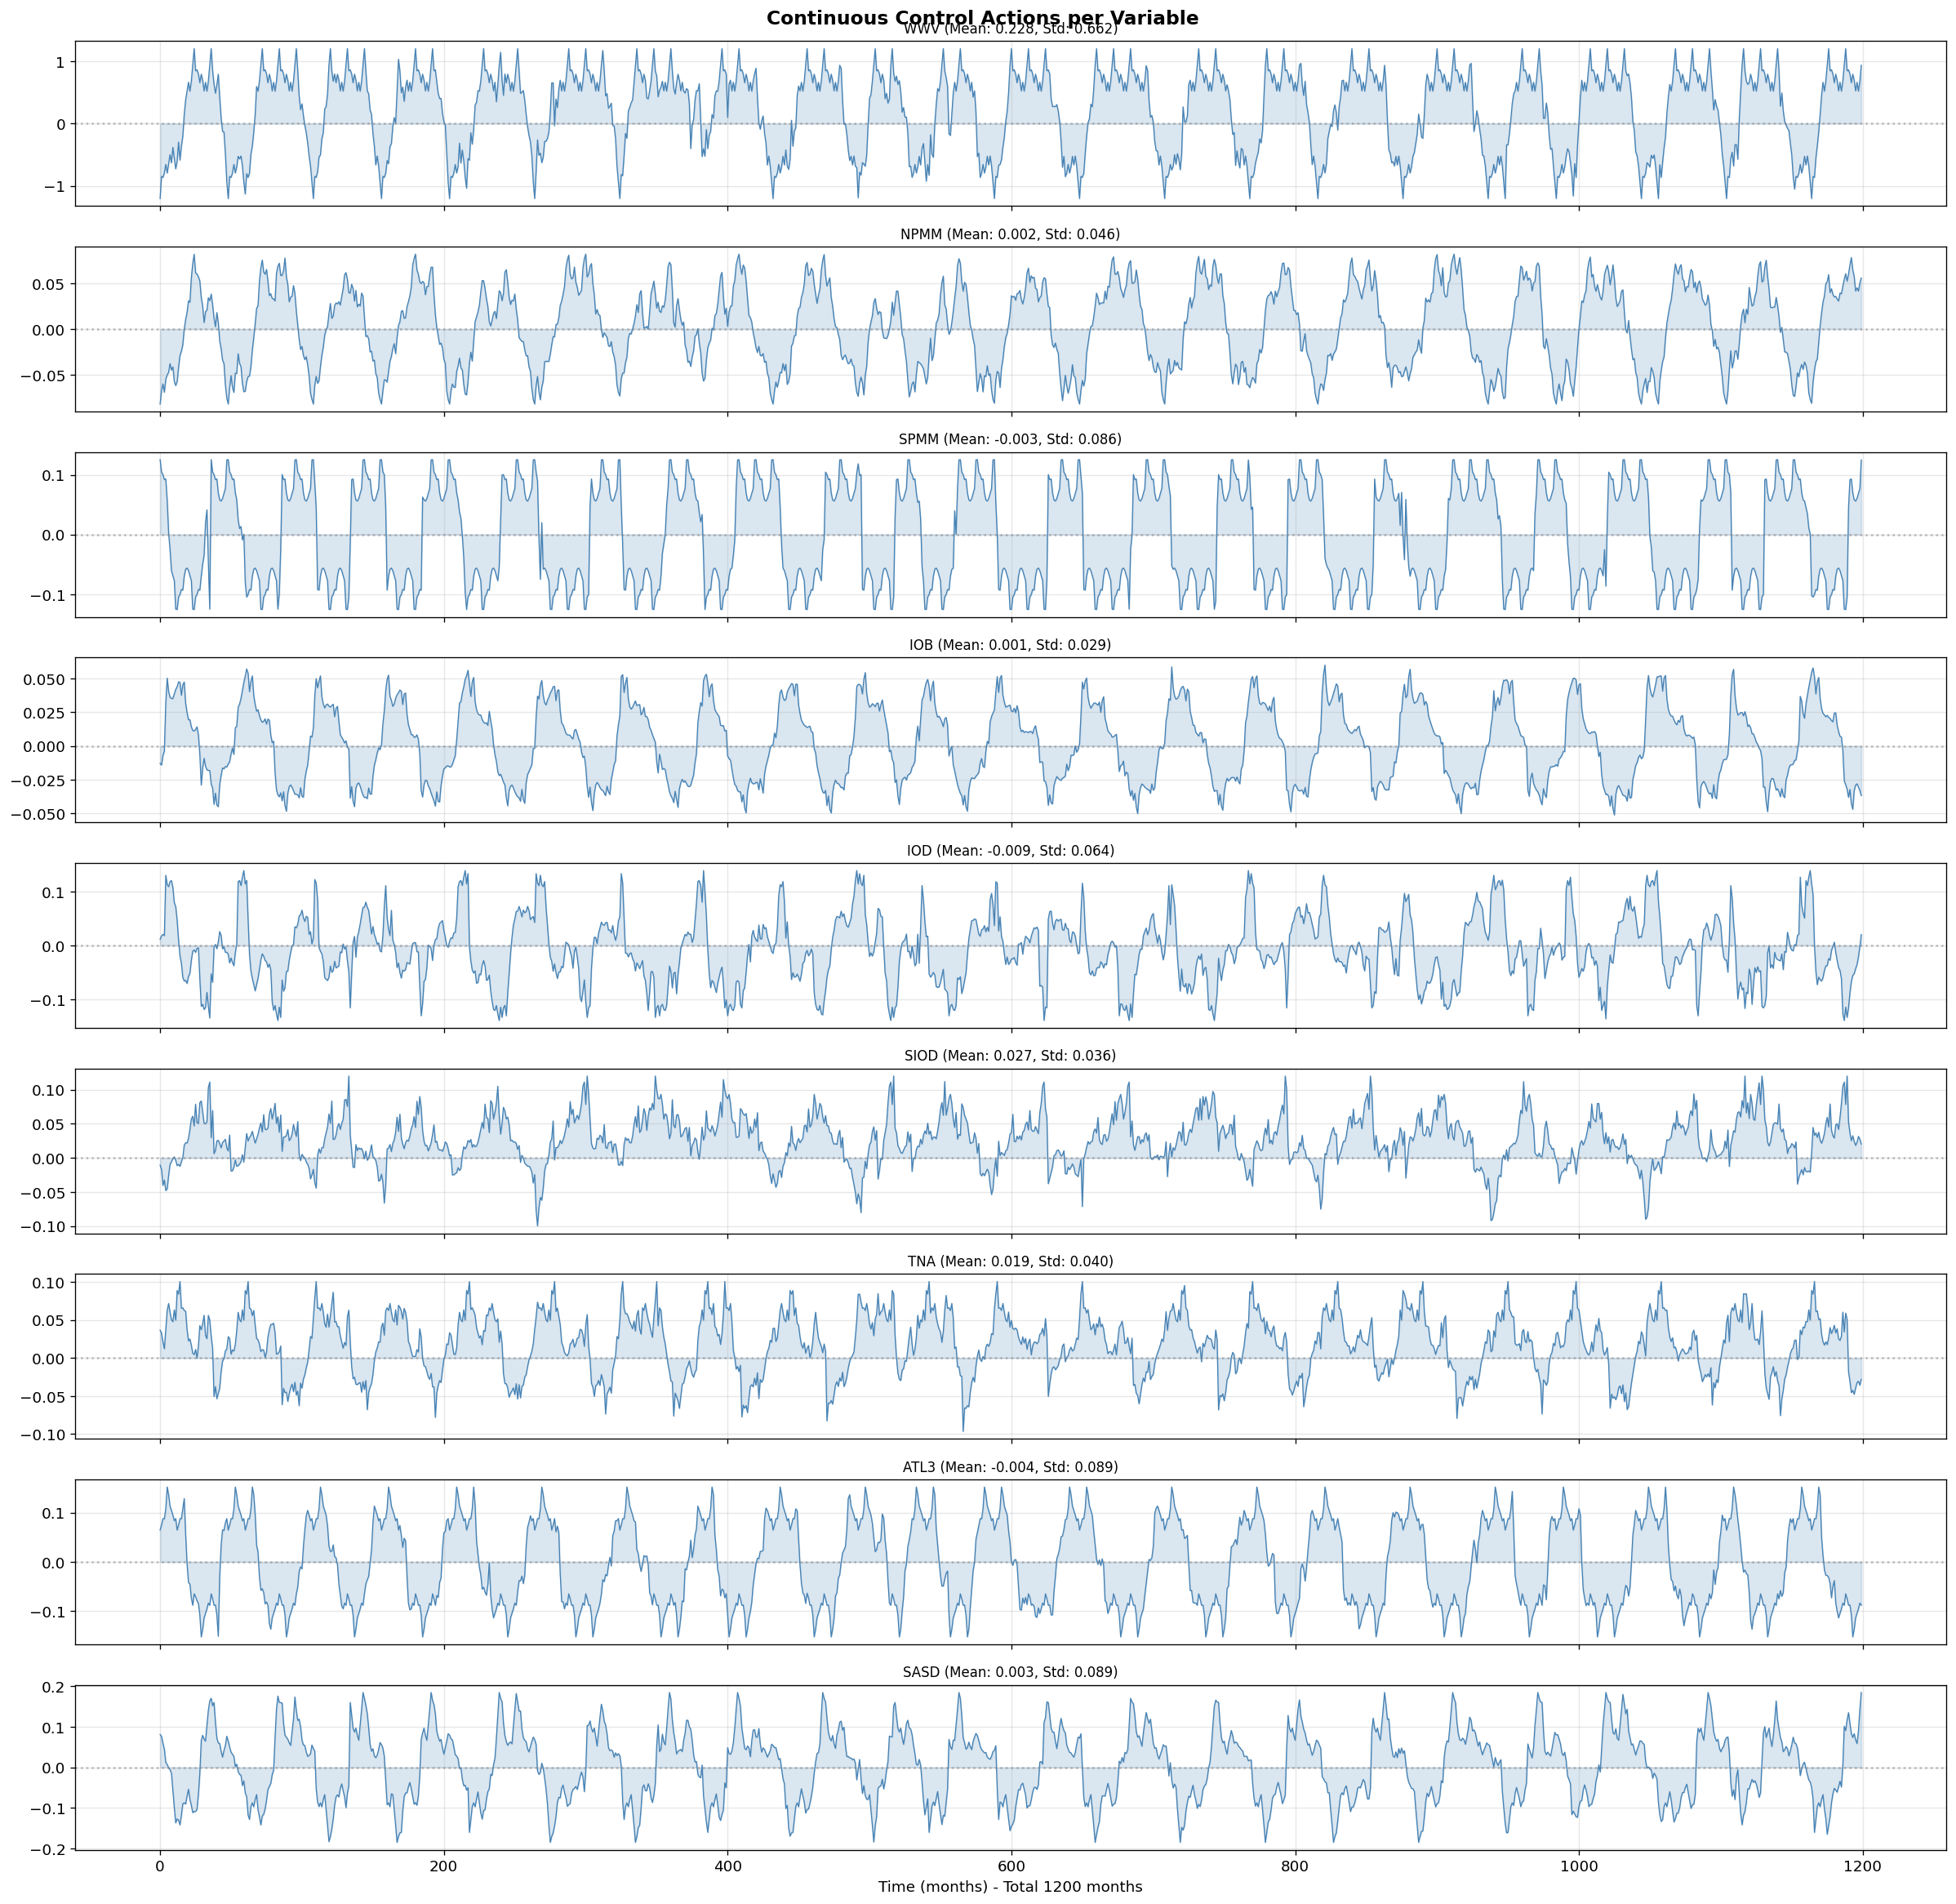

In [45]:
n_act = len(traj_action_names)
fig, axes = plt.subplots(n_act, 1, figsize=(20, n_act * 2.2), sharex=True)
fig.suptitle("Continuous Control Actions per Variable", fontsize=14, fontweight='bold')

for i, vname in enumerate(traj_action_names):
    ax = axes[i]
    ax.plot(actions_traj[:, i], linewidth=0.8, color='steelblue')
    ax.fill_between(range(T_traj), actions_traj[:, i], alpha=0.2, color='steelblue')
    ax.set_title(f'{vname} (Mean: {actions_traj[:, i].mean():.3f}, Std: {actions_traj[:, i].std():.3f})',
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel(f"Time (months) - Total {T_traj} months")
fig.tight_layout()
plt.show()

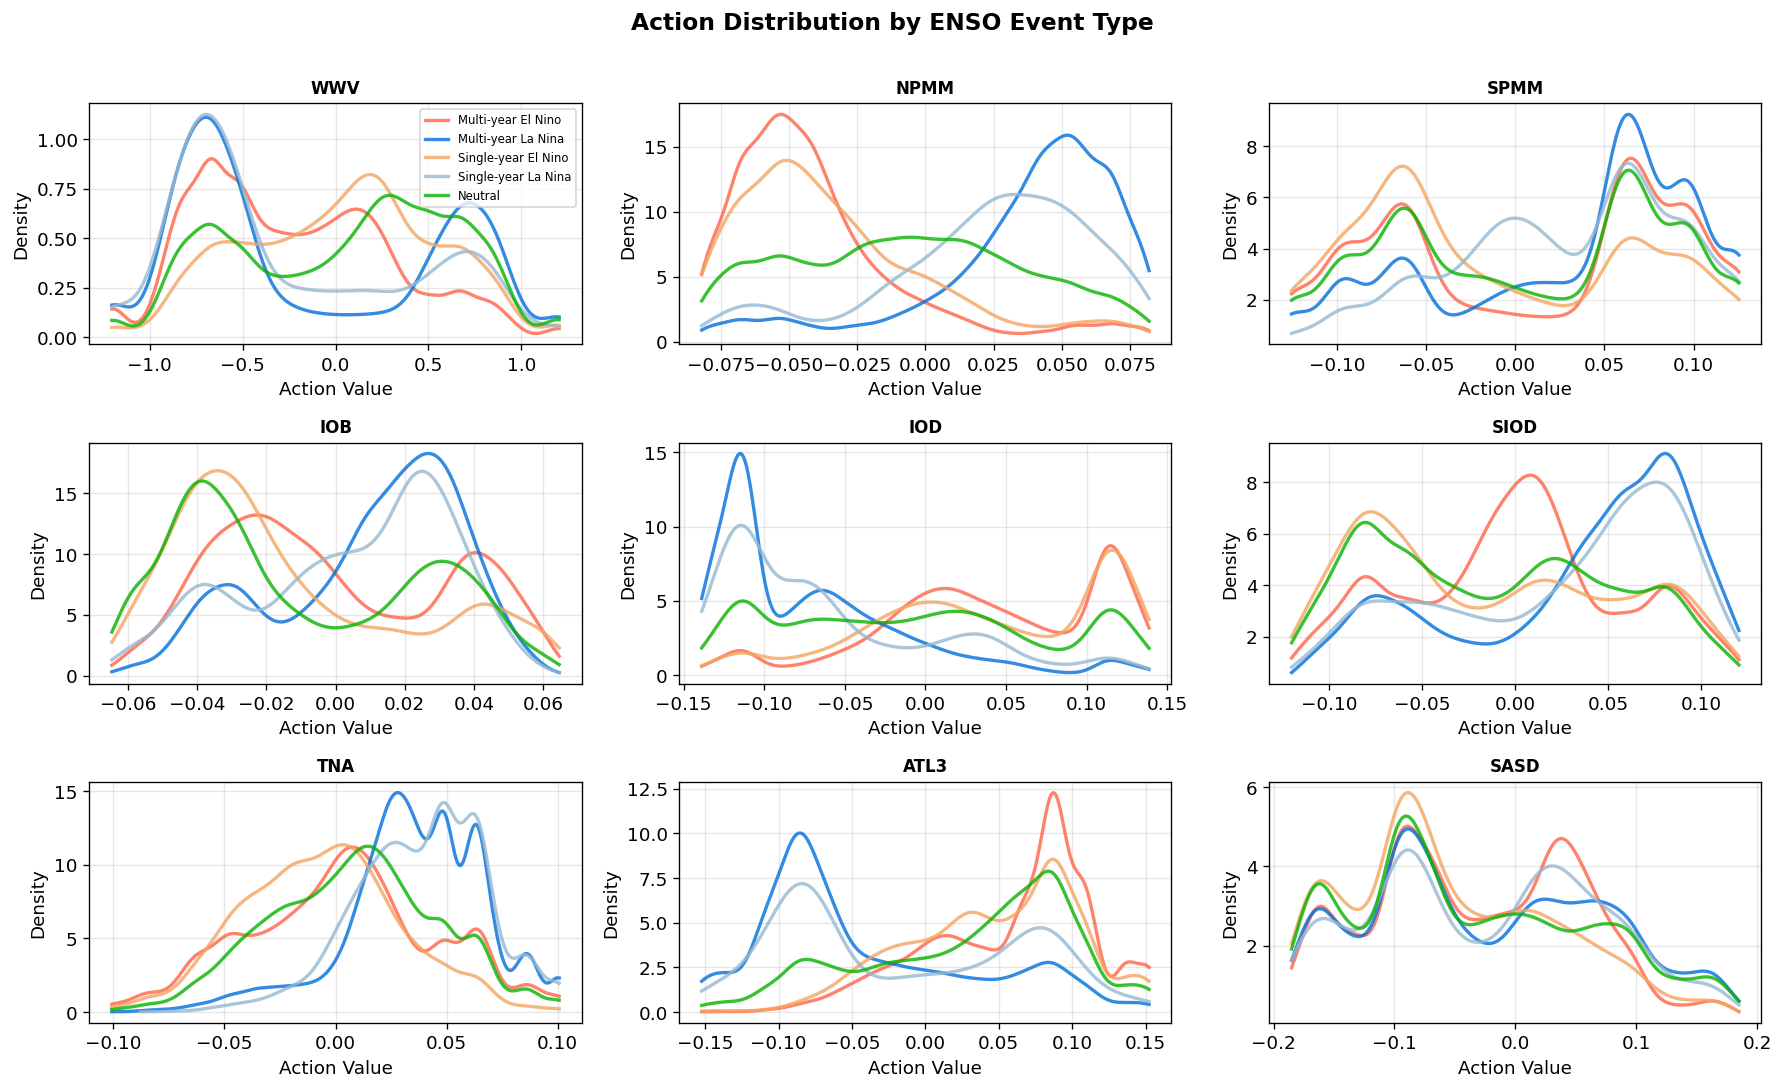

In [46]:
# Aggregated over ALL seeds x rollouts (not just the representative one) so each
# phase KDE has enough samples to be stable.
from scipy.stats import gaussian_kde

EVENT_ORDER      = [3, 4, 1, 2, 0]  # Multi-EN, Multi-LN, Single-EN, Single-LN, Neutral
kde_event_colors = {3: '#FF6347', 4: "#016EDB", 1: '#F4A460', 2: '#95B8D1', 0: "#09B200"}

all_labels = d_inf['agent_mye_label'].reshape(-1)   # [N]

def _kde_grid_by_event(data, names, title, xlabel, ncols=3, max_pts=20_000):
    """KDE of each column in `data`, one curve per ENSO phase, on a subplot grid."""
    rng = np.random.default_rng(0)
    n   = len(names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes_flat = np.atleast_1d(axes).ravel()

    for i, name in enumerate(names):
        ax  = axes_flat[i]
        col = data[:, i]
        for ev in EVENT_ORDER:
            vals = col[all_labels == ev]
            if len(vals) < 10 or vals.std() < 1e-9:
                continue
            if len(vals) > max_pts:
                vals = vals[rng.choice(len(vals), max_pts, replace=False)]
            xs = np.linspace(vals.min(), vals.max(), 300)
            ax.plot(xs, gaussian_kde(vals)(xs), color=kde_event_colors[ev],
                    linewidth=2, alpha=0.8, label=LABEL_NAMES[ev])
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[n:]:
        ax.set_visible(False)
    axes_flat[0].legend(fontsize=7, loc='best')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.005)
    fig.tight_layout()
    plt.show()

all_actions = d_inf['agent_actions'].reshape(-1, len(traj_action_names))
_kde_grid_by_event(all_actions, traj_action_names,
                   "Action Distribution by ENSO Event Type", "Action Value")

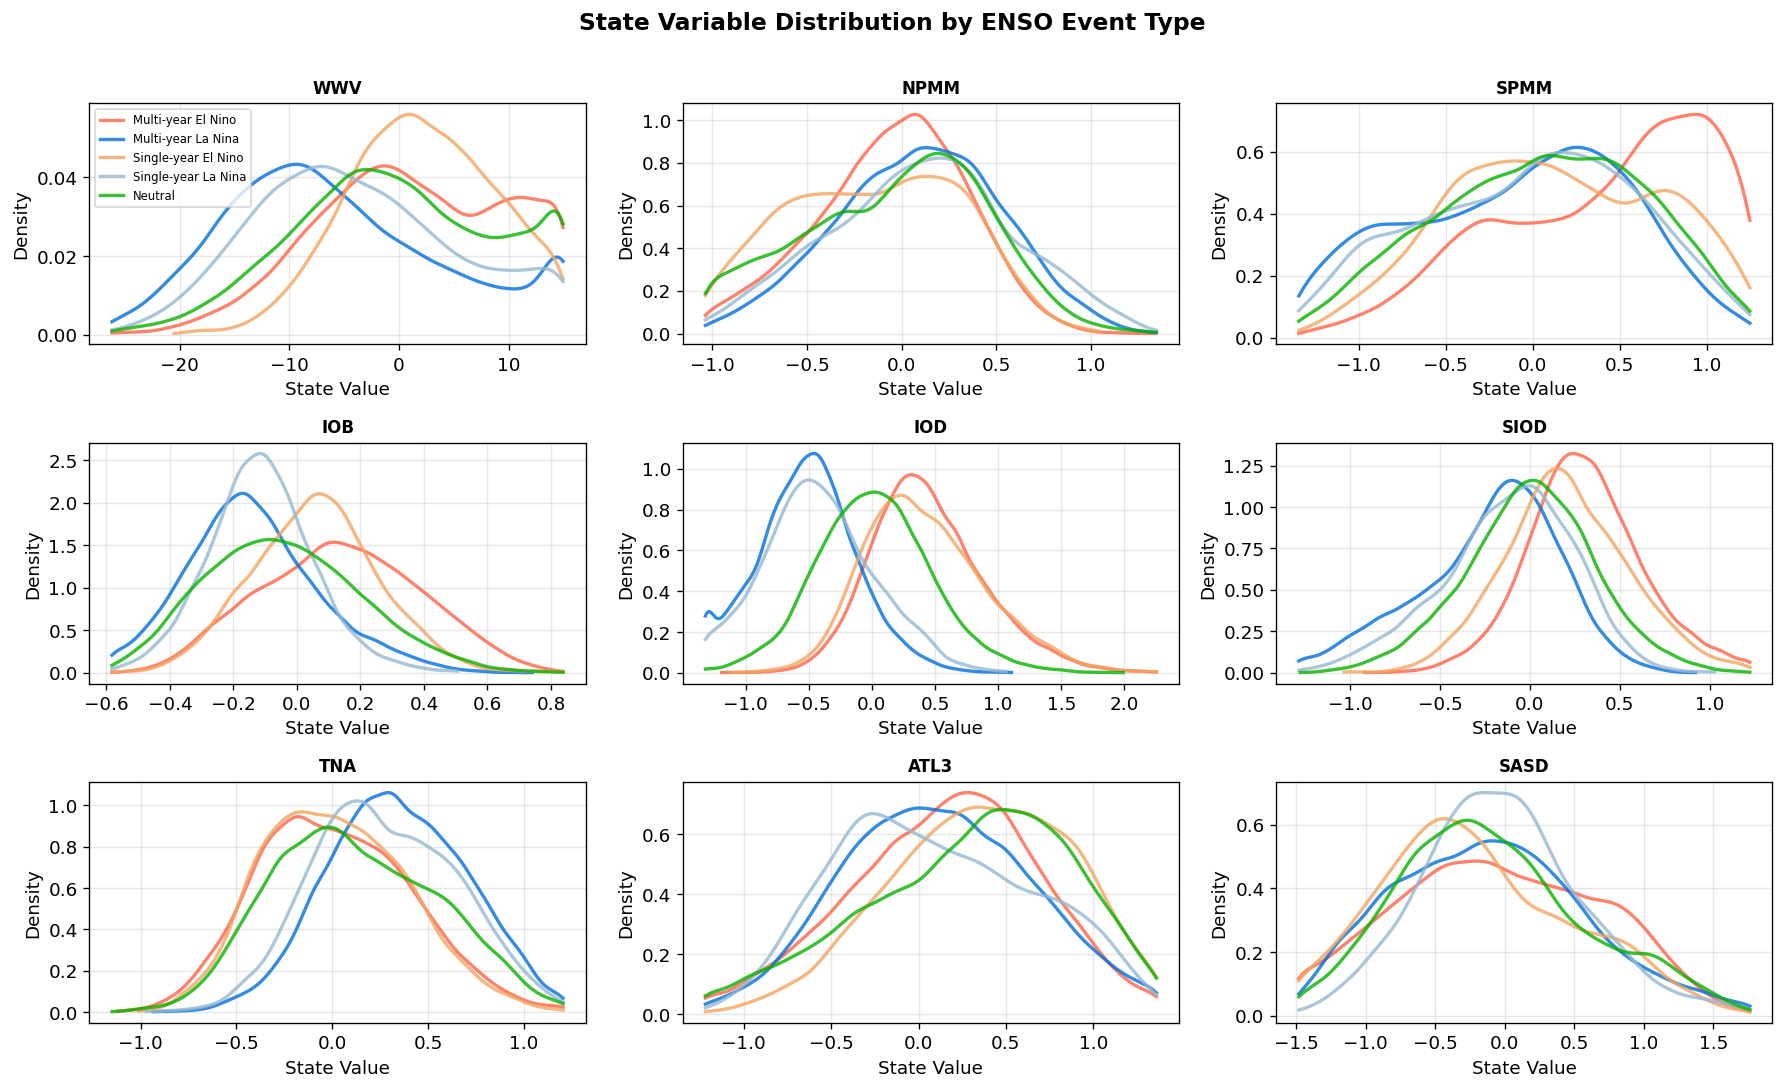

In [47]:
all_states = d_inf['agent_obs'].reshape(-1, len(traj_var_names))[:,1:] # slice to skip Nino34
_kde_grid_by_event(all_states, traj_var_names[1:],
                   "State Variable Distribution by ENSO Event Type", "State Value")

---
## 2. Lift Analysis

ΔP(MYE) = agent probability − baseline probability, decomposed into frequency and duration changes.

In [48]:
# Load raw inference data (replaces old lift_ensemble.npz + CSVs)
d_inf = _load_npz(BASE / "inference.npz")
agent_label   = d_inf['agent_mye_label']   # [n_seeds, n_rollouts, T]
base_label    = d_inf['base_mye_label']
inf_var_names = list(d_inf['var_names'])
n_seeds_inf, n_rollouts_inf, T_inf = agent_label.shape

# --- Lift per phase: fraction of steps in each MYE category ---
lift_per_rollout = {}
per_seed_lift    = {}
agent_frac_all   = {}
base_frac_all    = {}

for phase, fn in PHASE_MASKS.items():
    a_frac = fn(agent_label).mean(axis=-1)   # [n_seeds, n_rollouts]
    b_frac = fn(base_label).mean(axis=-1)
    agent_frac_all[phase]   = a_frac
    base_frac_all[phase]    = b_frac
    lift_per_rollout[phase] = a_frac - b_frac
    per_seed_lift[phase]    = lift_per_rollout[phase].mean(axis=1)  # [n_seeds]

# CI and p-value across seeds (each seed = mean of its rollouts)
lift_summary = {}
for phase in PHASES:
    arr = per_seed_lift[phase]
    _, pval = ttest_1samp(arr, 0.0)
    lift_summary[phase] = dict(
        lift=arr.mean(),
        ci95=t_dist.ppf(0.975, df=len(arr)-1) * arr.std(ddof=1) / np.sqrt(len(arr)),
        pval=pval,
    )

print(f"Loaded: {n_seeds_inf} seeds × {n_rollouts_inf} rollouts × {T_inf} months")
for phase in PHASES:
    s = lift_summary[phase]
    print(f"  {phase:<8}  lift={s['lift']:+.4f}  CI95=±{s['ci95']:.4f}  "
          f"p={s['pval']:.4f}  {_sig_stars(s['pval'])}")

Loaded: 5 seeds × 30 rollouts × 1200 months
  total     lift=+0.1737  CI95=±0.2531  p=0.1294  ns
  el_nino   lift=-0.0349  CI95=±0.1355  p=0.5139  ns
  la_nina   lift=+0.2086  CI95=±0.2518  p=0.0830  ns


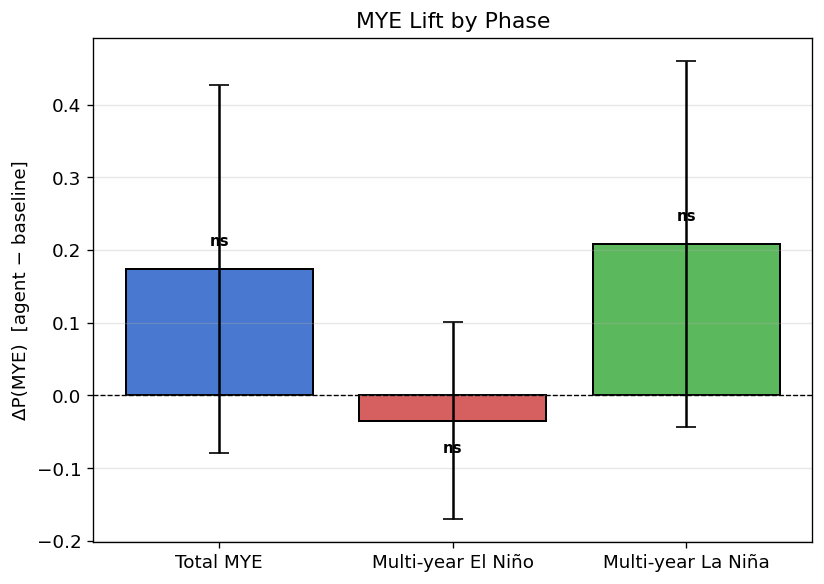

In [49]:
# --- 2a. Lift bar chart per phase ---
fig, ax = plt.subplots(figsize=(7, 5))
x      = np.arange(len(PHASES))
labels = [PHASE_LABELS[p] for p in PHASES]
lifts  = np.array([lift_summary[p]['lift']  for p in PHASES])
ci95   = np.array([lift_summary[p]['ci95']  for p in PHASES])
pvals  = np.array([lift_summary[p]['pval']  for p in PHASES])
colors = [PHASE_COLORS[p] for p in PHASES]

ax.bar(x, lifts, color=colors, edgecolor="black", linewidth=1.2,
       yerr=ci95, capsize=6, error_kw={"linewidth": 1.5})
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
_add_sig_labels(ax, x, lifts, pvals)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("ΔP(MYE)  [agent − baseline]")
ax.set_title("MYE Lift by Phase")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

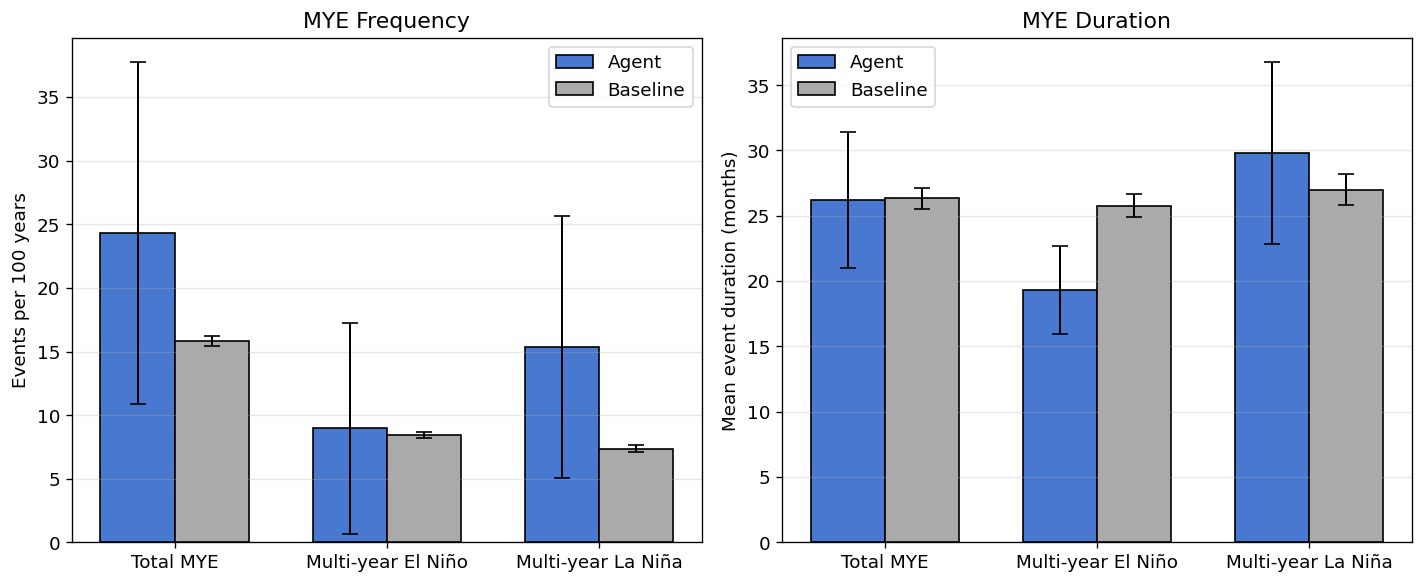

In [50]:
# --- 2b. Frequency & duration decomposition ---
# Count events and measure durations from raw labels via _find_continuous_runs
years_per_rollout = T_inf / 12
century_scale     = 100.0 / years_per_rollout

freq_agent = {p: np.zeros(n_seeds_inf) for p in PHASES}
freq_base  = {p: np.zeros(n_seeds_inf) for p in PHASES}
dur_agent  = {p: np.zeros(n_seeds_inf) for p in PHASES}
dur_base   = {p: np.zeros(n_seeds_inf) for p in PHASES}

for si in range(n_seeds_inf):
    for phase, fn in PHASE_MASKS.items():
        cnts_a, durs_a, cnts_b, durs_b = [], [], [], []
        for ri in range(n_rollouts_inf):
            runs_a = _find_continuous_runs(fn(agent_label[si, ri]).astype(int))
            cnts_a.append(len(runs_a))
            durs_a.extend([r[2] for r in runs_a])
            runs_b = _find_continuous_runs(fn(base_label[si, ri]).astype(int))
            cnts_b.append(len(runs_b))
            durs_b.extend([r[2] for r in runs_b])
        freq_agent[phase][si] = np.mean(cnts_a) * century_scale
        freq_base[phase][si]  = np.mean(cnts_b) * century_scale
        dur_agent[phase][si]  = np.mean(durs_a) if durs_a else 0.0
        dur_base[phase][si]   = np.mean(durs_b) if durs_b else 0.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x      = np.arange(len(PHASES))
labels = [PHASE_LABELS[p] for p in PHASES]
w      = 0.35

ax = axes[0]
for i, phase in enumerate(PHASES):
    mA, cA = _mean_ci(freq_agent[phase])
    mB, cB = _mean_ci(freq_base[phase])
    ax.bar(i - w/2, mA, w, label="Agent"    if i == 0 else "", color="#4878CF",
           yerr=cA, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
    ax.bar(i + w/2, mB, w, label="Baseline" if i == 0 else "", color="#aaaaaa",
           yerr=cB, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Events per 100 years")
ax.set_title("MYE Frequency")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
for i, phase in enumerate(PHASES):
    mA, cA = _mean_ci(dur_agent[phase])
    mB, cB = _mean_ci(dur_base[phase])
    ax.bar(i - w/2, mA, w, label="Agent"    if i == 0 else "", color="#4878CF",
           yerr=cA, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
    ax.bar(i + w/2, mB, w, label="Baseline" if i == 0 else "", color="#aaaaaa",
           yerr=cB, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Mean event duration (months)")
ax.set_title("MYE Duration")
ax.legend(); ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

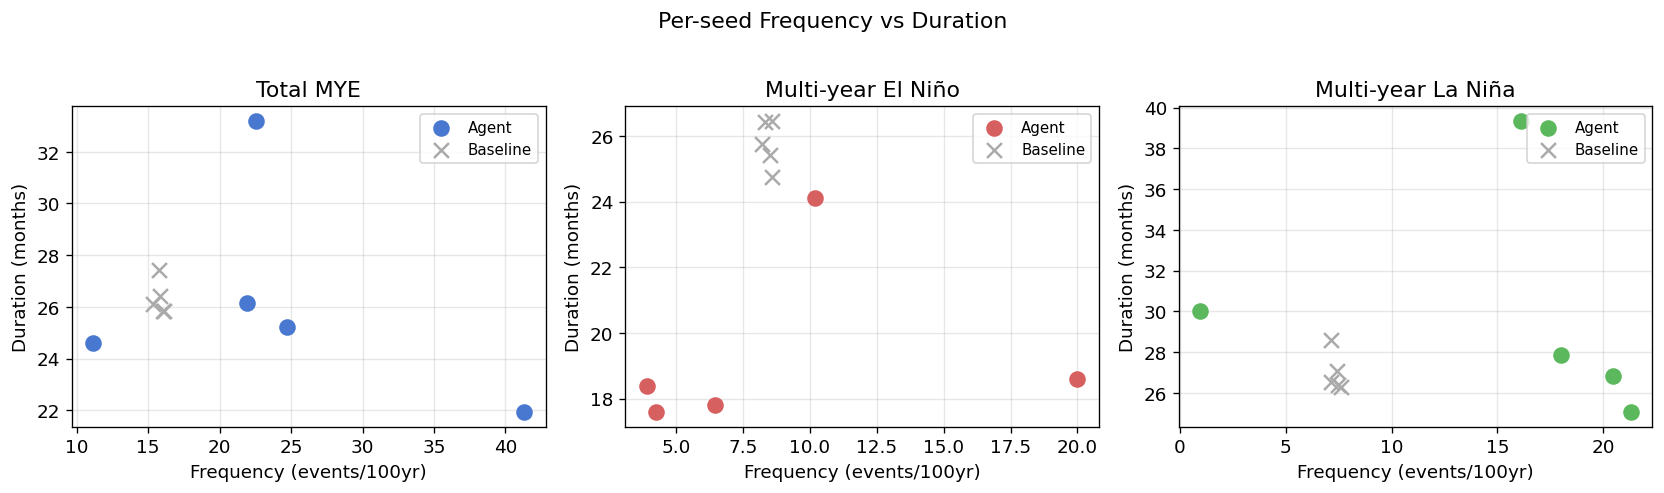

In [51]:
# --- 2c. Per-seed freq–duration scatter (robustness check) ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(14, 4), sharey=False)
for ax, phase in zip(axes, PHASES):
    ax.scatter(freq_agent[phase], dur_agent[phase],
               color=PHASE_COLORS[phase], s=80, zorder=3, label="Agent")
    ax.scatter(freq_base[phase], dur_base[phase],
               color="#aaaaaa", marker="x", s=80, zorder=3, label="Baseline")
    ax.set_xlabel("Frequency (events/100yr)")
    ax.set_ylabel("Duration (months)")
    ax.set_title(PHASE_LABELS[phase])
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.suptitle("Per-seed Frequency vs Duration", y=1.02)
fig.tight_layout()
plt.show()

---
## 3. Seed Sensitivity — EN/LN Lift Asymmetry

Per-seed multi-year El Niño vs La Niña lift (from `inference.npz`). Checks whether the phase asymmetry is consistent across independently trained agents.

In [52]:
# per_seed_lift computed in Section 2 (Lift Analysis) from inference.npz
lift_en = per_seed_lift['el_nino']   # [n_seeds]
lift_ln = per_seed_lift['la_nina']   # [n_seeds]
n_seeds = len(lift_en)
print(f"Seeds: {n_seeds}  |  El Niño lift: {lift_en.mean():.3f} ± {lift_en.std():.3f}")
print(f"                    La Niña lift: {lift_ln.mean():.3f} ± {lift_ln.std():.3f}")

Seeds: 5  |  El Niño lift: -0.035 ± 0.098
                    La Niña lift: 0.209 ± 0.181


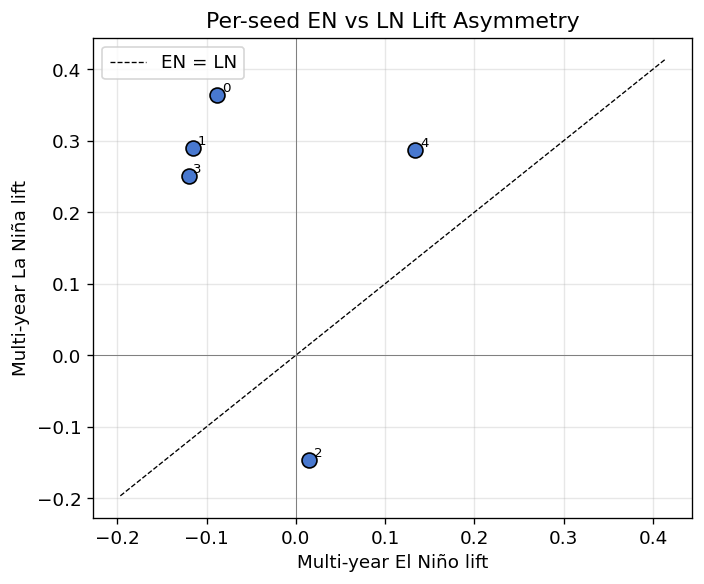

In [53]:
# --- 3a. EN vs LN lift scatter per seed ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lift_en, lift_ln, s=80, color="#4878CF", edgecolor="black", zorder=3)
for i, (x_, y_) in enumerate(zip(lift_en, lift_ln)):
    ax.text(x_ + 0.005, y_ + 0.005, str(i), fontsize=8)
lims = [min(lift_en.min(), lift_ln.min()) - 0.05,
        max(lift_en.max(), lift_ln.max()) + 0.05]
ax.plot(lims, lims, "k--", linewidth=0.8, label="EN = LN")
ax.axhline(0, color="grey", linewidth=0.6); ax.axvline(0, color="grey", linewidth=0.6)
ax.set_xlabel("Multi-year El Niño lift"); ax.set_ylabel("Multi-year La Niña lift")
ax.set_title("Per-seed EN vs LN Lift Asymmetry")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

---
## 4. Seasonality of Control

When in the seasonal cycle does the agent act most strongly? Highlights the spring predictability barrier (Mar–May).

In [ ]:
# Reuse already-loaded d_inf (inference.npz) for seasonality.
# Stored agent_actions are SCALED forcing (action * action_scale); undo the scaling
# to recover the agent's RAW action (in [-1, 1]) so effort is comparable across modes.
from config import EnvConfig

actions = d_inf['agent_actions']            # [n_seeds, n_rollouts, T, 9] (scaled forcing)
n_modes = actions.shape[-1]
drivers = list(d_inf['action_names'])       # 9 forcing modes (no Nino3.4)
T_seas  = actions.shape[2]
SPINUP_seas = int(d_inf['spinup'])          # == 12

# Per-rollout calendar month of step 0. reset() starts the seasonal clock at the
# sampled state's month (not January), so we must bin by the TRUE calendar month
# (step + start_month) % 12, not step % 12. Fall back for older inference.npz.
if 'rollout_start_month' in d_inf.files:
    start_month = d_inf['rollout_start_month']          # [n_seeds, n_rollouts]
else:
    start_month = np.zeros((n_seeds_inf, n_rollouts_inf), dtype=int)
    print("WARNING: rollout_start_month missing - re-run inference.py; binning by step%12.")

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
spring_idx  = [2, 3, 4]

# Undo the per-month scaling applied at storage time (evaluation.py scales by step % 12),
# recovering the raw policy action. action_scale is [9, 12] (Jan..Dec, already halved).
step_month   = np.arange(T_seas) % 12
action_scale = np.array(EnvConfig().action_scale)
raw_actions  = actions / action_scale[:, step_month].T      # broadcast -> [.,.,T,9]

# Bin RAW action by TRUE calendar month per rollout, skipping the SPINUP transient.
keep = np.arange(T_seas) >= SPINUP_seas
abs_by_month    = np.full((n_seeds_inf, n_rollouts_inf, 12, n_modes), np.nan)
signed_by_month = np.full((n_seeds_inf, n_rollouts_inf, 12, n_modes), np.nan)
for si in range(n_seeds_inf):
    for ri in range(n_rollouts_inf):
        cal_month = (np.arange(T_seas) + int(start_month[si, ri])) % 12
        for m in range(12):
            sel = keep & (cal_month == m)
            if sel.any():
                abs_by_month[si, ri, m, :]    = np.abs(raw_actions[si, ri, sel, :]).mean(0)
                signed_by_month[si, ri, m, :] = raw_actions[si, ri, sel, :].mean(0)

# Ensemble mean over seeds x rollouts (nanmean guards a month a short rollout may miss)
abs_mean    = np.nanmean(abs_by_month, axis=(0, 1))      # [12, n_modes]
signed_mean = np.nanmean(signed_by_month, axis=(0, 1))   # [12, n_modes]
total_by_month = abs_mean.sum(axis=1)                    # [12]

spring_frac = total_by_month[spring_idx].sum() / total_by_month.sum()
print(f"Spring (Mar-May) share: {spring_frac*100:.1f}%  (even = 25.0%)")
print(f"Modes: {drivers}")

In [ ]:
# --- 4a. Month x mode heatmap (raw action effort) ---
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(abs_mean.T, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(12)); ax.set_xticklabels(month_names)
ax.set_yticks(range(n_modes)); ax.set_yticklabels(drivers)
ax.set_title("Mean |Raw Action| by Calendar Month x Mode")
plt.colorbar(im, ax=ax, label="Mean |raw action|")
fig.tight_layout()
plt.show()

In [ ]:
# --- 4b. Monthly total raw-action bar ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(12), total_by_month, color="#90CAF9", edgecolor="black", linewidth=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(month_names)
ax.set_ylabel("Total |raw action| (sum over modes)")
ax.set_title("Monthly Raw-Action Total")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

---
## 5. State Variable KDE

Distribution of XRO mode values under agent vs baseline. Reveals how the agent reshapes the climate state — beyond just MYE fractions — across all 10 state variables.

In [57]:
from scipy.stats import gaussian_kde

agent_obs = d_inf['agent_obs']   # [n_seeds, n_rollouts, T, 10]
base_obs  = d_inf['base_obs']    # [n_seeds, n_rollouts, T, 10]
kde_vars  = list(d_inf['var_names'])   # ['Nino3.4', 'WWV', ...]
n_vars    = agent_obs.shape[-1]

# Flatten over seeds × rollouts × time for KDE
agent_flat = agent_obs.reshape(-1, n_vars)   # [N, 10]
base_flat  = base_obs.reshape(-1, n_vars)

print(f"KDE samples per variable: {agent_flat.shape[0]:,}  (agent)  "
      f"{base_flat.shape[0]:,}  (baseline)")
print(f"Variables: {kde_vars}")

KDE samples per variable: 180,000  (agent)  180,000  (baseline)
Variables: [np.str_('Nino34'), np.str_('WWV'), np.str_('NPMM'), np.str_('SPMM'), np.str_('IOB'), np.str_('IOD'), np.str_('SIOD'), np.str_('TNA'), np.str_('ATL3'), np.str_('SASD')]


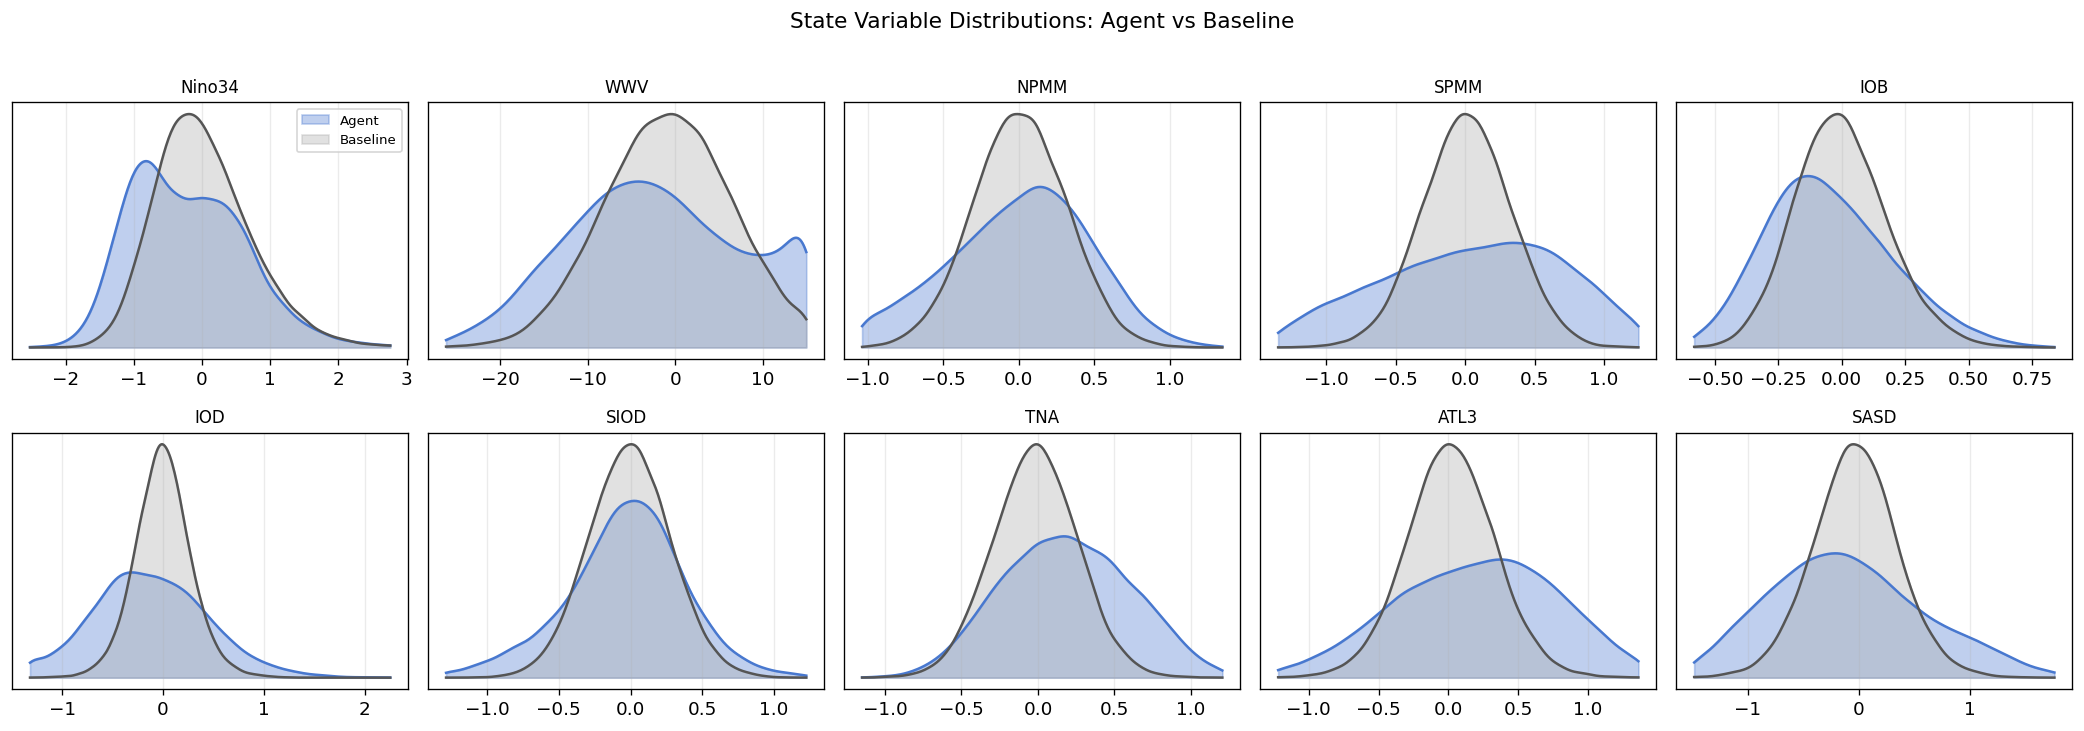

In [58]:
# --- 5. KDE grid: agent vs baseline for each state variable ---
# Subsample for speed (KDE on 360 k points is slow)
rng_kde = np.random.default_rng(0)
max_pts = 50_000
idx_a   = rng_kde.choice(agent_flat.shape[0], min(max_pts, agent_flat.shape[0]), replace=False)
idx_b   = rng_kde.choice(base_flat.shape[0],  min(max_pts, base_flat.shape[0]),  replace=False)

ncols = 5
nrows = int(np.ceil(n_vars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes_flat = axes.ravel()

for vi, vname in enumerate(kde_vars):
    ax = axes_flat[vi]
    a_vals = agent_flat[idx_a, vi]
    b_vals = base_flat[idx_b, vi]

    lo = min(a_vals.min(), b_vals.min())
    hi = max(a_vals.max(), b_vals.max())
    xs = np.linspace(lo, hi, 300)

    kde_a = gaussian_kde(a_vals, bw_method=0.15)
    kde_b = gaussian_kde(b_vals, bw_method=0.15)

    ax.fill_between(xs, kde_a(xs), alpha=0.35, color="#4878CF", label="Agent")
    ax.fill_between(xs, kde_b(xs), alpha=0.35, color="#aaaaaa", label="Baseline")
    ax.plot(xs, kde_a(xs), color="#4878CF", linewidth=1.5)
    ax.plot(xs, kde_b(xs), color="#555555", linewidth=1.5)
    ax.set_title(vname, fontsize=10)
    ax.set_yticks([])
    ax.grid(alpha=0.25)

# Hide unused axes
for ax in axes_flat[n_vars:]:
    ax.set_visible(False)

axes_flat[0].legend(fontsize=8, loc="upper right")
fig.suptitle("State Variable Distributions: Agent vs Baseline", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()